In [ ]:
import pandas as pd
import numpy as np
import re # for the text count in amenities

import pandas as pd
# Load your CSV
df = pd.read_csv("/content/Ireland AirBnB Listings .csv")

# Availability message
df["Availability Message"] = df["has_availability"].apply(
lambda x: "This property is currently available"
if str(x).lower() in ["true", "t", "1"]
else "This property is currently unavailable"
)

# Instant Bookable message
df["Instant Bookable Message"] = df["instant_bookable"].apply(
lambda x: "It can be booked now."
if str(x).lower() == "t"
else "Apologies, this property cannot be booked instantly. The host will be in touch about your stay."
)

# Combined message in a presentable sentence (optional)
df["Property Message"] = df["Availability Message"] + ". " + df["Instant Bookable Message"]

# Transform area into county column. Remove unessary text and group dublins areas into Dublin. iloc or loc may work
df.loc[df['region_parent_name'] == 'Fingal', 'region_parent_name'] = 'Dublin'
df.rename(columns={'region_parent_name': 'County'}, inplace=True)

# Transform date columns to datetime
date_columns = [
    'host_since',
    'first_review',
    'last_review',
    'calendar_last_scraped',
    'last_scraped'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 1. Quality and Trust Metrics

# Overall Quality Score (weighted average, boost if Superhost)
review_cols = ['review_scores_rating', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_accuracy', 'review_scores_communication', 'review_scores_location', 'review_scores_value']
df['Overall_Quality_Score'] = df[review_cols].mean(axis=1)
df['Overall_Quality_Score'] *= np.where(df['host_is_superhost'].astype(str).str.lower().isin(['t']), 1.2, 1.0)

# Host Reliability Score (simple average, discuss with Guilherme if there could be additional weights to this)
reliability_cols = ['host_response_rate', 'host_acceptance_rate']
for col in reliability_cols:
    df[col] = pd.to_numeric(df[col].str.rstrip('%')) / 100
df['host_identity_verified_flag'] = df['host_identity_verified'].astype(str).str.lower().isin(['t']).astype(int)
df['Host_Reliability_Score'] = df[reliability_cols + ['host_identity_verified_flag']].mean(axis=1)

# Days until first review (days between host_since and first_review)
df['host_since'] = pd.to_datetime(df['host_since'])
df['first_review'] = pd.to_datetime(df['first_review']) #Review if you need this after you created your new date function
df['Review_Velocity_Days'] = (df['first_review'] - df['host_since']).dt.days

# Review Age (months since last_review) - How old is this last review?
df['calendar_last_scraped'] = pd.to_datetime(df['calendar_last_scraped'])
df['last_review'] = pd.to_datetime(df['last_review']) #Ensure date variable exists
df['Review_Age_Months'] = ((df['calendar_last_scraped'] - df['last_review']).dt.days / 30).round(1) # Set the number to an appropriate decimal place after subtraction calculation

# 2. Value and Pricing Metrics

# Price per Guest
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float) # Do a lot of testing on this since it took a few tries to get this working
df['Price_per_Guest'] = df['price'] / df['accommodates'].replace(0, np.nan) # Simple division, replace 0 with NaN to avoid confusion price per guest outputs

# Price per Bedroom
df['Price_per_Bedroom'] = df['price'] / df['bedrooms'].replace(0, np.nan) # Same idea as price per guest code above

# Use a function to count amenities items in each string
def count_amenity_items(amenities):
    # Finds all substrings within double quotes
    return len(re.findall(r'"(.*?)"', str(amenities))) # Len is used to count how many strings were found in each. Make sure that amenities is a string, read strings using regular expression function and use .? to catch anything between double quotes

df['Amenities_Item_Count'] = df['amenities'].apply(count_amenity_items) # If the above works, create a new column

# If the above function fails (count_amentiy_items), try this, it doesn't depend on regex (hopefully you fix the regex issue)
# def count_amenity_items(amenities):
    # Remove brackets and split by comma
    #items = [a.strip() for a in str(amenities)[1:-1].split(',') if a.strip()]
    #return len(items)

# Minimum Stay Flexibility # Basically we want to create parameters around minimum nights and then group them into categories
def min_stay_flex(row):
    if row['minimum_nights'] <= 2:
        return 'Highly Flexible'
    elif row['minimum_nights'] <= 7:
        return 'Moderately Flexible'
    else:
        return 'Long Stay Only'
df['Minimum_Stay_Flexibility'] = df.apply(min_stay_flex, axis=1) # Add new column to dateset with this

# 3. Availability and Occupancy Metrics

# Occupancy Rate (90-Day) - Usig error -> coerce to handle errors without throwing code errors as some of these may be blank or non-numeric
df['availability_90'] = pd.to_numeric(df['availability_90'], errors='coerce')
df['Occupancy_Rate_90d'] = 1 - (df['availability_90'] / 90) # Try to build a proportion here, 1 - (available days / total days in period). Test if this works otherwise add plenty of ### to this and review it later

# Occupancy Rate (365-Day) - Usig error -> coerce to handle errors without throwing code errors as some of these may be blank or non-numeric
df['availability_365'] = pd.to_numeric(df['availability_365'], errors='coerce')
df['Occupancy_Rate_365d'] = 1 - (df['availability_365'] / 365) # Try to build a proportion here, 1 - (available days / total days in period). Test if this works otherwise add plenty of ### to this and review it later

# Listing Age (Years)
df['last_scraped'] = pd.to_datetime(df['last_scraped'], errors='coerce')
df['Listing_Age_Years'] = ((df['last_scraped'] - df['host_since']).dt.days / 365).round(2)  # Is there a better name for this variable?

# Revenue Density (Divide the estimated revenue in last 365 days by the number of people a listing can accommodate)
df['Revenue_Density'] = df['estimated_revenue_l365d'] / df['accommodates'].replace(0, np.nan)

# Save to Colab's local disk
df.to_csv("Airbnb_transformed_dataset.csv", index=False)

/tmp/ipython-input-2860465355.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=county_revenue.values, y=county_revenue.index, palette='viridis')


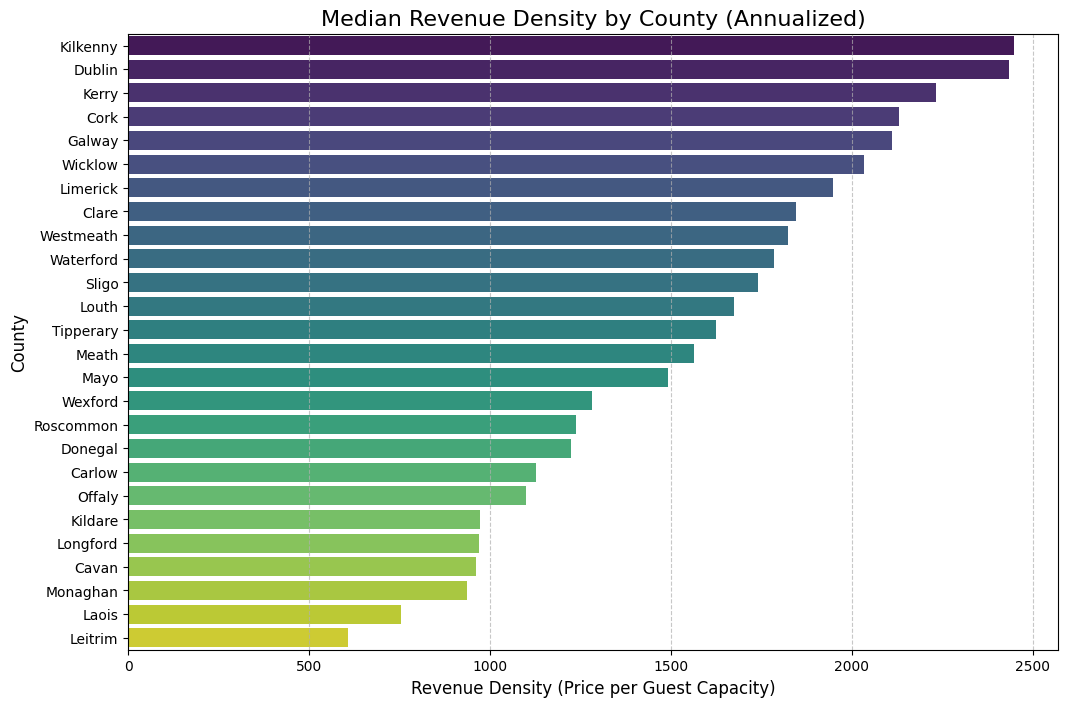

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average revenue density per county
county_revenue = df.groupby('County')['Revenue_Density'].median().sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=county_revenue.values, y=county_revenue.index, palette='viridis')

# Add titles and labels
plt.title('Median Revenue Density by County (Annualized)', fontsize=16)
plt.xlabel('Revenue Density (Price per Guest Capacity)', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save the plot locally in Colab
plt.savefig('county_revenue_density.png', bbox_inches='tight')
plt.show()

In [ ]:
# 1. Strip out the 'Council' text (case-insensitive)
# We use regex to find "county council" or "city council" and replace with nothing
df['County'] = df['County'].str.replace(r'(?i)\s*(county|City)\s*council', '', regex=True)
df['County'] = df['County'].str.replace(r'(?i)\s*(And|City)\s*council', '', regex=True)

# 2. Map the specific Dublin administrative areas to one 'Dublin' label
dublin_areas = [
    'Dublin City',
    'Dun Laoghaire-Rathdown',
    'Fingal',
    'South Dublin',
    'Dun Laoghaire-rathdown'
]

# This checks if the value is in our list and changes it to 'Dublin'
df.loc[df['County'].str.strip().isin(dublin_areas), 'County'] = 'Dublin'

# 3. Final clean-up: Strip any leftover trailing/leading whitespace
df['County'] = df['County'].str.strip()

# Check the results
print(df['County'].unique())

['Mayo' 'Clare' 'Galway' 'Kilkenny' 'Dublin' 'Sligo' 'Cavan' 'Cork'
 'Roscommon' 'Wicklow' 'Kerry' 'Donegal' 'Limerick City And' 'Carlow'
 'Kildare' 'Tipperary' 'Meath' 'Longford' 'Westmeath' 'Offaly' 'Wexford'
 'Monaghan' 'Waterford City And' 'Leitrim' 'Louth' 'Laois']


In [ ]:
# 1. Targeted Clean for Waterford and Limerick
# Try to replace the specific "City And" leftovers
df['County'] = df['County'].str.replace(r'(?i)city\s+and', '', regex=True)

# 2. Check for any remaining 'City' or 'Council' words
# \b ensures I only match whole words
words_to_remove = [r'(?i)\bcity\b', r'(?i)\bcouncil\b', r'(?i)\bcounty\b']
for word in words_to_remove:
    df['County'] = df['County'].str.replace(word, '', regex=True)

# 3. Aggregating Dublin (in case any extra stuff slipped through)
dublin_vars = ['Fingal', 'Rathdown', 'South Dublin', 'Dublin City']
for area in dublin_vars:
    df.loc[df['County'].str.contains(area, case=False, na=False), 'County'] = 'Dublin'

# 4. Final Polish
df['County'] = df['County'].str.strip()

# Check the results - should be exactly 26
print(sorted(df['County'].unique()))
print(f"Total Unique Counties: {len(df['County'].unique())}")

['Carlow', 'Cavan', 'Clare', 'Cork', 'Donegal', 'Dublin', 'Galway', 'Kerry', 'Kildare', 'Kilkenny', 'Laois', 'Leitrim', 'Limerick', 'Longford', 'Louth', 'Mayo', 'Meath', 'Monaghan', 'Offaly', 'Roscommon', 'Sligo', 'Tipperary', 'Waterford', 'Westmeath', 'Wexford', 'Wicklow']
Total Unique Counties: 26


/tmp/ipython-input-2860465355.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=county_revenue.values, y=county_revenue.index, palette='viridis')


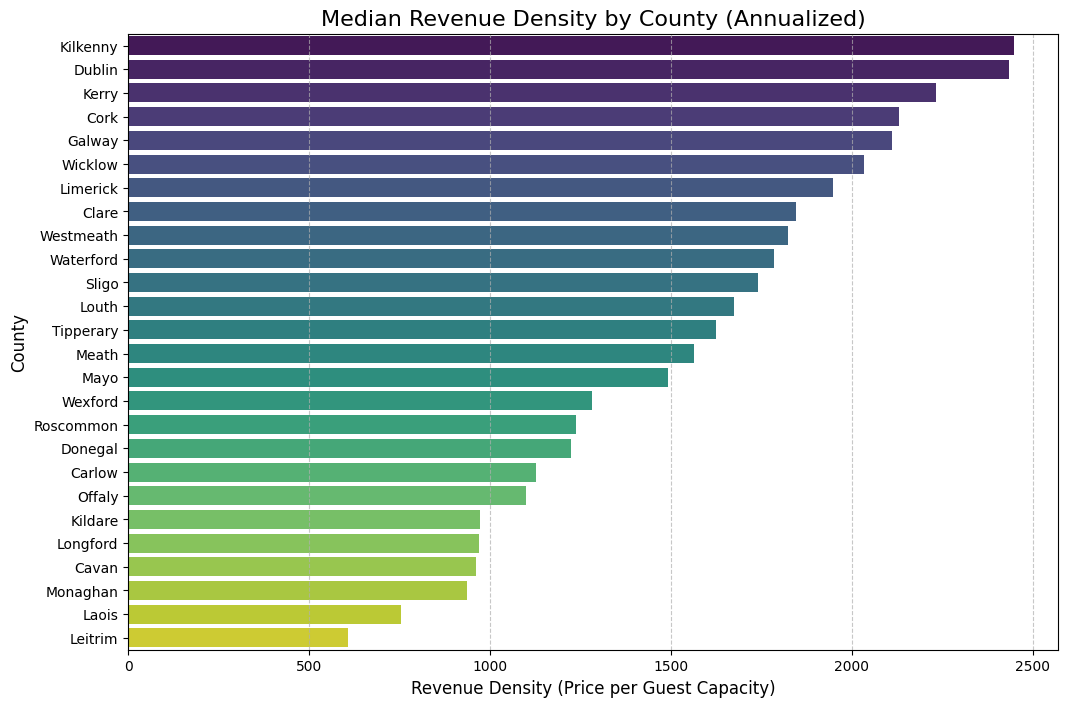

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average revenue density per county
county_revenue = df.groupby('County')['Revenue_Density'].median().sort_values(ascending=False)

# Create the plot
plt.figure(figsize=(12, 8))
sns.barplot(x=county_revenue.values, y=county_revenue.index, palette='viridis')

# Add titles and labels
plt.title('Median Revenue Density by County (Annualized)', fontsize=16)
plt.xlabel('Revenue Density (Price per Guest Capacity)', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save the plot locally in Colab
plt.savefig('county_revenue_density.png', bbox_inches='tight')
plt.show()

In [ ]:
# Create a comprehensive summary table
overall_analysis = df.groupby('County')['Revenue_Density'].agg(['median', 'mean', 'sum', 'count']).sort_values(by='sum', ascending=False)

# Rename columns for clarity
overall_analysis.columns = ['Median Density', 'Mean Density', 'Total Revenue Density', 'Number of Listings']

# Format the numbers for the report
pd.options.display.float_format = '{:,.2f}'.format
print(overall_analysis)

           Median Density  Mean Density  Total Revenue Density  \
County                                                           
Dublin           2,434.00      4,948.72          27,029,934.68   
Kerry            2,231.62      3,795.09          10,929,856.15   
Galway           2,112.00      4,097.02          10,902,173.01   
Cork             2,130.00      3,780.23           9,272,909.52   
Clare            1,846.80      3,498.12           5,271,673.52   
Donegal          1,225.00      2,199.70           5,026,303.61   
Mayo             1,491.00      2,505.39           3,560,164.87   
Wicklow          2,032.50      3,861.05           2,586,902.11   
Wexford          1,282.45      2,358.52           2,231,157.15   
Kilkenny         2,448.00      4,781.07           1,802,463.86   
Waterford        1,785.00      2,647.64           1,646,833.58   
Sligo            1,741.12      2,946.88           1,473,441.07   
Meath            1,563.00      2,642.02           1,321,009.67   
Tipperary 

In [ ]:
overall_analysis.to_csv("county_performance_summary.csv", index=True)

In [ ]:
import chardet

file_path = "PPR-2025.csv"

# Read a small chunk of the file to detect encoding
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read(10000))  # Look at the first 10k bytes
    print(f"Detected Encoding: {result['encoding']} with {result['confidence']*100}% confidence")

Detected Encoding: Windows-1252 with 73.0% confidence


In [ ]:
import pandas as pd

# 1. Load with the confirmed encoding
ppr = pd.read_csv("PPR-2025.csv", encoding='cp1252')

# 2. Clean the Price column
# Remove €, commas, and convert to float
ppr['Price'] = ppr['Price (€)'].replace(r'[\€,]', '', regex=True).astype(float)

# 3. Apply the 13.5% VAT adjustment for 'VAT Exclusive' sales
ppr['Final_Price'] = ppr.apply(
    lambda x: x['Price'] * 1.135 if "VAT Exclusive" in str(x['VAT Exclusive']) else x['Price'],
    axis=1
)

# 4. Standardize Counties to match Airbnb (e.g., 'Dublin', 'Galway')
# Removes 'Co.' and trims whitespace
ppr['County'] = ppr['County'].str.replace('Co. ', '', regex=False).str.strip()

# 5. Export for the repo
ppr.to_csv("PPR_2025_Cleaned.csv", index=False)

# Quick stats for the report for follow up with supervisor
print(f"Total sales in 2025 dataset: {len(ppr)}")
print(f"Median adjusted house price: €{ppr['Final_Price'].median():,.2f}")

Total sales in 2025 dataset: 61715
Median adjusted house price: €353,000.00
